In [28]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# Parâmetros físicos (em unidades atômicas)
alpha = 1.0  # intensidade do potencial periódico
n_vals = np.array([-2,-1,1,2])             
G_vals = 2 * np.pi * n_vals # G_n = 2πn
N = len(G_vals) # Dimensão da matriz
beta = 10.0   # intensidade do segundo termo de acoplamento
sigma = 10.0

# Valores de k dentro da 1ª zona de Brillouin: -π < k ≤ π
k_vals = np.linspace(-np.pi, np.pi, 200, endpoint=False)
bands = np.zeros((len(k_vals), N))  # armazenar autovalores para cada k


In [30]:
# Loop sobre todos os valores de k
for i, k in enumerate(k_vals):
    delta_k = k - G_vals
    lambda_vals = delta_k**2  # energia cinética |k - G|^2

    # Monta Hamiltoniano tridiagonal
    H = np.zeros((N, N))
    for j in range(N):
    # termo alpha de acoplamento
        H[j, j] = lambda_vals[j]
        if j > 0:
            H[j, j - 1] = alpha
        if j < N - 1:
            H[j, j + 1] = alpha
    # termo beta de acoplamento
        if j > 1:
            H[j, j - 2] = beta
        # Segunda diagonal acima da principal
        if j < N - 2:
            H[j, j + 2] = beta
    # termo sigma de acoplamento gaussiano
        if j > 2:
            H[j, j - 3] = sigma
        if j < N - 3:
            H[j, j + 3] = sigma


    # Diagonaliza H(k)
    eigvals = np.linalg.eigvalsh(H)
    bands[i, :] = eigvals  # salva autovalores ordenados


In [31]:
# Visualização da matriz
print("Matriz H(k) para k =", k)
print(H)

Matriz H(k) para k = 3.1101767270538954
[[245.75413655   1.          10.          10.        ]
 [  1.          88.23525031   1.          10.        ]
 [ 10.           1.          10.06798345   1.        ]
 [ 10.          10.           1.          89.41960283]]


In [32]:
 # Calcula os autovalores (energias) e autovetores (coeficientes C)
eigenvalues, eigenvectors = np.linalg.eigh(H)

print("\nEnergias (autovalores) para k =", k)
print(np.sort(eigenvalues))


Energias (autovalores) para k = 3.1101767270538954
[  9.63015678  78.58300496  98.42878457 246.83502682]


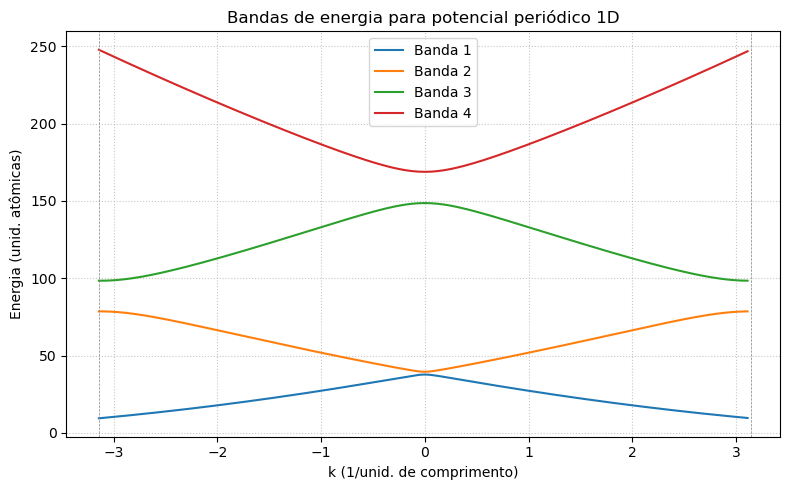

In [33]:
# Plotando o diagrama de bandas
plt.figure(figsize=(8, 5))
for n in range(N):
    plt.plot(k_vals, bands[:, n], label=f"Banda {n+1}")
plt.title("Bandas de energia para potencial periódico 1D")
plt.xlabel("k (1/unid. de comprimento)")
plt.ylabel("Energia (unid. atômicas)")
plt.axvline(x=-np.pi, color='gray', linestyle='--', linewidth=0.5)
plt.axvline(x=np.pi, color='gray', linestyle='--', linewidth=0.5)
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()